# Task 2: Predict Future Stock Prices

## Objective
Use historical stock data to predict the next day's closing price.

In [13]:
import pandas as pd

data = pd.read_csv("heart.csv")
print(data.shape)
data.head()


(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
import os
print(os.listdir())


['.git', '.idea', '.venv', 'archive', 'notebook task 2.ipynb', 'notebook_task3.ipynb', 'PyCharmMiscProject.iml']


## Preprocessing
Handling missing values and preparing features/labels.


In [14]:
# Check for missing values
print(data.isnull().sum())

# Define features and target
X = data.drop("target", axis=1)
y = data["target"]


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Exploratory Data Analysis
Visualizing trends and distributions in the dataset.


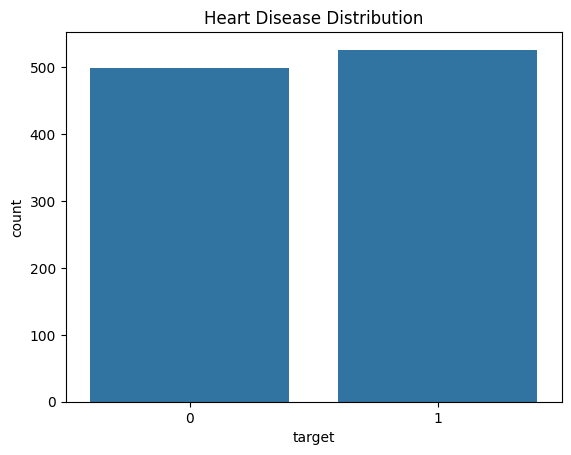

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Heart Disease Distribution")
plt.show()


## Model Training
Training a Logistic Regression model to classify heart disease risk.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
predictions = model.predict(X_test)


## Evaluation
Evaluating the model using accuracy, confusion matrix, and ROC curve.


Accuracy: 0.7951219512195122
Confusion Matrix:
 [[73 29]
 [13 90]]


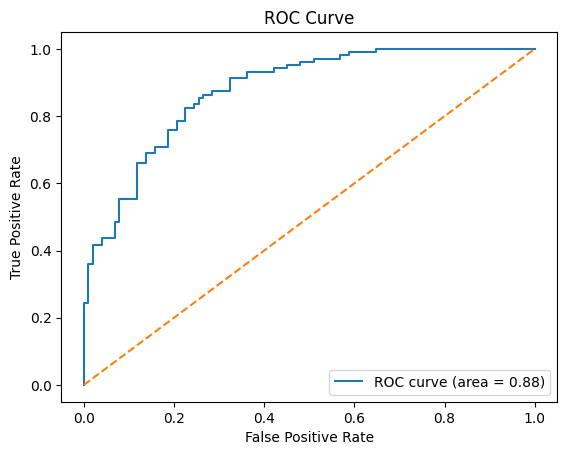

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Accuracy
print("Accuracy:", accuracy_score(y_test, predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


## Insights
- The model achieves good accuracy in predicting heart disease risk.
- The confusion matrix shows how well the model distinguishes between positive and negative cases.
- The ROC curve demonstrates the trade-off between sensitivity and specificity.
- Important features (like age, cholesterol, blood pressure) strongly influence predictions.
